In [4]:
#ingest

from ingest import fetch_news, chunk_articles, embed_and_upsert
from collections import defaultdict

articles = fetch_news(page_size=100)
chunks = chunk_articles(articles)
embed_and_upsert(chunks)

by_outlet = defaultdict(list)
for c in chunks:
    by_outlet[c["outlet"]].append(c["title"])

print(f"✓ {len(chunks)} articles ingested\n")
for outlet, titles in by_outlet.items():
    print(f"{outlet}: {len(titles)} articles → \"{titles[0][:60]}...\"")

Fetched 100 articles from NewsAPI
Created 100 chunks
Cleared existing Pinecone vectors


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Upserted batch 1
Upserted batch 2
Done — 100 chunks in Pinecone
✓ 100 articles ingested

Al Jazeera English: 63 articles → "Israel says four soldiers killed as army pushes deeper into ..."
Associated Press: 5 articles → "Average price for a gallon of gas in the US eclipses $4..."
Fox News: 21 articles → "Why Trump faces an agonizing decision on obliterating Iran’s..."
CNN: 7 articles → "Live updates: Iran war news, Kuwaiti oil tanker attack, Trum..."
BBC News: 4 articles → "US President says he's still talking to Iran..."


In [1]:
from rag import query_pipeline

QUERY = "US Iran war military strikes"

result = query_pipeline(QUERY)

print(f"Query: {result['query']}\n")
print("── OUTLET SCORES (ranked by neural engagement) ─────────")
for c in result["outlet_scores"]:
    bar = "█" * max(1, int(abs(c["engagement_score"]) * 500))
    sign = "+" if c["engagement_score"] >= 0 else ""
    print(f"  {sign}{c['engagement_score']:.4f}  {c['outlet']:<25} {bar}")
    print(f"           {c['title'][:65]}...")

print("\n── CLAUDE ANALYSIS ─────────────────────────────────────")
print(result["answer"])


 Query: US Iran war military strikes
Retrieved 50 chunks from Pinecone
Filtered to 5 outlets: ['Al Jazeera English', 'Fox News', 'CNN', 'Associated Press', 'BBC News']
TRIBE re-ranked 5 outlet chunks
Query: US Iran war military strikes

── OUTLET SCORES (ranked by neural engagement) ─────────
  +0.0672  Al Jazeera English        █████████████████████████████████
           US-Israel war on Iran: What’s happening on day 30 of attacks?...
  +0.0593  BBC News                  █████████████████████████████
           US President says he's still talking to Iran...
  +0.0363  Associated Press          ██████████████████
           TRUMP THREATENS CIVILIAN INFRASTRUCTURE...
  +0.0361  Fox News                  ██████████████████
           Iran's internet blackout hiding strike damage and suppressing dis...
  -0.0338  CNN                       ████████████████
           Iran’s nuclear program: Cornered and wounded, will Tehran now rac...

── CLAUDE ANALYSIS ────────────────────────────────

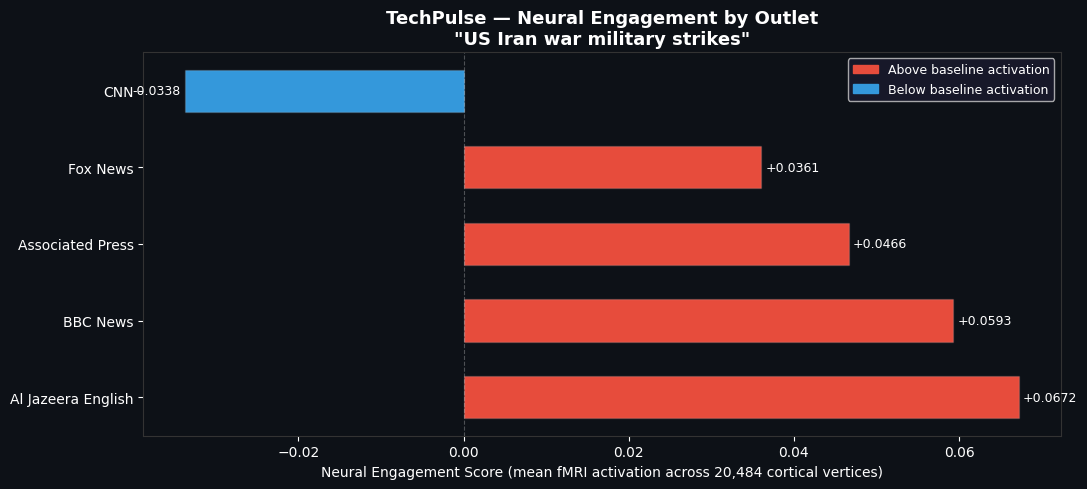

✓ Saved outlet_comparison.png


In [5]:
#neural engagement bar chart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

outlets = [c["outlet"] for c in result["outlet_scores"]]
scores = [c["engagement_score"] for c in result["outlet_scores"]]
colors = ["#e74c3c" if s > 0 else "#3498db" for s in scores]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")

bars = ax.barh(outlets, scores, color=colors, edgecolor="#ffffff22", height=0.55)
ax.axvline(x=0, color="#ffffff44", linewidth=0.8, linestyle="--")

for bar, score in zip(bars, scores):
    ax.text(
        score + 0.0005 if score >= 0 else score - 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f"{score:+.4f}", va="center",
        ha="left" if score >= 0 else "right",
        color="white", fontsize=9
    )

ax.set_xlabel("Neural Engagement Score (mean fMRI activation across 20,484 cortical vertices)", 
              color="white", fontsize=10)
ax.set_title(f'TechPulse — Neural Engagement by Outlet\n"{QUERY}"',
             color="white", fontsize=13, fontweight="bold")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

pos_patch = mpatches.Patch(color="#e74c3c", label="Above baseline activation")
neg_patch = mpatches.Patch(color="#3498db", label="Below baseline activation")
ax.legend(handles=[pos_patch, neg_patch], facecolor="#1a1a2e", 
          labelcolor="white", fontsize=9)

plt.tight_layout()
plt.savefig("outlet_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("✓ Saved outlet_comparison.png")


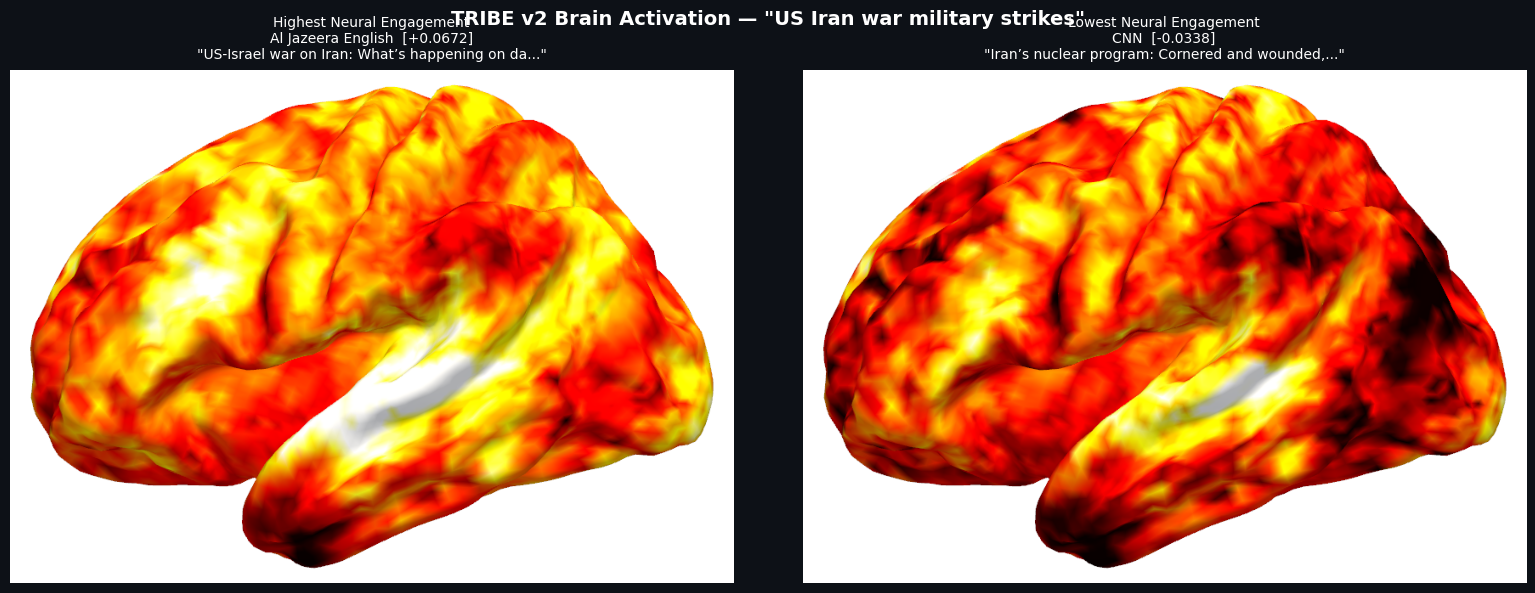

✓ Saved brain_comparison.png

Top:    Al Jazeera English [+0.0672] — more cortical activation
Bottom: CNN [-0.0338] — less cortical activation


In [10]:
# get global min/max across both
import numpy as np
import matplotlib.pyplot as plt

from tribev2.plotting import PlotBrain

plotter = PlotBrain(mesh="fsaverage5")

top = result["outlet_scores"][0]
bottom = result["outlet_scores"][-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0d1117")
fig.suptitle(
    f'TRIBE v2 Brain Activation — "{QUERY}"',
    fontsize=14, color="white", fontweight="bold"
)

all_activations = np.concatenate([
    np.array(top["brain_activation"]),
    np.array(bottom["brain_activation"])
])
vmin = float(np.percentile(all_activations, 1))
vmax = float(np.percentile(all_activations, 99))

for ax, chunk, label in zip(axes, [top, bottom], 
                             ["Highest Neural Engagement", "Lowest Neural Engagement"]):
    activation = np.array(chunk["brain_activation"])
    plotter.plot_surf(
        activation,
        axes=ax,
        cmap="hot",
        vmin=vmin,
        vmax=vmax,
    )
    ax.axis("off")
    ax.set_title(
        f"{label}\n{chunk['outlet']}  [{chunk['engagement_score']:+.4f}]\n"
        f"\"{chunk['title'][:45]}...\"",
        color="white", fontsize=10, pad=8
    )

plt.tight_layout()
plt.savefig("brain_comparison2.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("✓ Saved brain_comparison.png")
print(f"\nTop:    {top['outlet']} [{top['engagement_score']:+.4f}] — more cortical activation")
print(f"Bottom: {bottom['outlet']} [{bottom['engagement_score']:+.4f}] — less cortical activation")